# Survey analysis using Pandas

Author: Ye Joo Park ([ypark32@illinois.edu](mailto:ypark32@illinois.edu))

- Data Source: [FiveThirtyEight - GitHub Repository](https://github.com/fivethirtyeight/data/tree/master/flying-etiquette-survey) 
- Relevant Article: [FiveThirtyEight - 41 Percent of Fliers Think You're Rude if You Recline Your Seat](https://fivethirtyeight.com/features/airplane-etiquette-recline-seat/)
- Data License: [CC-BY 4.0](https://creativecommons.org/licenses/by/4.0/)

In 2014, FiveThirtyEight ran a SurveyMonkey Audience poll of 1,040 U.S. respondents about airplane etiquette — reclining, armrests, window shades, babies, and waking up your seatmate. The headline result was that 41% of fliers think reclining your seat is rude. This notebook goes beyond the topline percentages and asks:

1. **Who actually answered the etiquette questions?** (How did the survey treat people who never fly?)
2. **Which behaviors do fliers consider rude**, and does the *reason* behind a behavior change the verdict?
3. **The recline paradox:** do people who recline think it is fine, and how many recline while believing it is rude?
4. **Does height** explain who reclines?
5. **Do parents** judge babies and unruly children differently?
6. **Do age and gender** shape etiquette views?
7. **Who are the rule breakers** (electronics during takeoff, smoking in the lavatory), and do they also recline more?
8. **Shared-space norms:** armrests and the window shade.

In [1]:
import pandas as pd
import numpy as np

In [2]:
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 200)

In [3]:
pd.options.display.max_colwidth

200

### Read data

In [4]:
df = pd.read_csv('flying-etiquette.csv')
df

,RespondentID,How often do you travel by plane?,Do you ever recline your seat when you fly?,How tall are you?,Do you have any children under 18?,"In a row of three seats, who should get to use the two arm rests?","In a row of two seats, who should get to use the middle arm rest?",Who should have control over the window shade?,Is itrude to move to an unsold seat on a plane?,"Generally speaking, is it rude to say more than a few words tothe stranger sitting next to you on a plane?","On a 6 hour flight from NYC to LA, how many times is it acceptable to get up if you're not in an aisle seat?","Under normal circumstances, does a person who reclines their seat during a flight have any obligation to the person sitting behind them?",Is it rude to recline your seat on a plane?,"Given the opportunity, would you eliminate the possibility of reclining seats on planes entirely?",Is it rude to ask someone to switch seats with you in order to be closer to friends?,Is itrude to ask someone to switch seats with you in order to be closer to family?,Is it rude to wake a passenger up if you are trying to go to the bathroom?,Is itrude to wake a passenger up if you are trying to walk around?,"In general, is itrude to bring a baby on a plane?","In general, is it rude to knowingly bring unruly children on a plane?",Have you ever used personal electronics during take off or landing in violation of a flight attendant's direction?,Have you ever smoked a cigarette in an airplane bathroom when it was against the rules?,Gender,Age,Household Income,Education,Location (Census Region)
0,3436139758,Once a year or less,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3434278696,Once a year or less,About half the time,"6'3""",Yes,The arm rests should be shared,The arm rests should be shared,Everyone in the row should have some say,"No, not rude at all","No, not at all rude",Twice,"Yes, they should not recline their chair if the person behind them asks them not to","Yes, somewhat rude",No,"No, not at all rude","No, not at all rude","No, not at all rude","No, not at all rude","No, not at all rude","No, not at all rude",No,No,Male,30-44,NaN,Graduate degree,Pacific
2,3434275578,Once a year or less,Usually,"5'8""",No,Whoever puts their arm on the arm rest first,The arm rests should be shared,The person in the window seat should have exclusive control,"No, not rude at all","No, not at all rude",Three times,"Yes, they should not recline their chair if the person behind them asks them not to","No, not rude at all",No,"No, not at all rude","No, not at all rude","No, not at all rude","Yes, somewhat rude","Yes, somewhat rude","Yes, very rude",No,No,Male,30-44,"$100,000 - $149,999",Bachelor degree,Pacific
3,3434268208,Once a year or less,Always,"5'11""",No,The arm rests should be shared,The arm rests should be shared,Everyone in the row should have some say,"No, not rude at all","No, not at all rude",Three times,"No, the person on the flight has no obligation to the person behind them","No, not rude at all",No,"Yes, somewhat rude","No, not at all rude","No, not at all rude","Yes, somewhat rude","Yes, somewhat rude","Yes, very rude",No,No,Male,30-44,"$0 - $24,999",Bachelor degree,Pacific
4,3434250245,Once a month or less,About half the time,"5'7""",No,The person in the middle seat gets both arm rests,The person in aisle,Everyone in the row should have some say,"No, not rude at all","No, not at all rude",Twice,"No, the person on the flight has no obligation to the person behind them","No, not rude at all",No,"No, not at all rude","No, not at all rude","Yes, somewhat rude","Yes, somewhat rude","Yes, somewhat rude","Yes, very rude",Yes,No,Male,30-44,"$50,000 - $99,999",Bachelor degree,Pacific
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1035,3431732652,Once a year or less,Once in a while,"5'7""",No,Other (please specify),Other (please specify),Everyone in the 

How many rows and columns?

In [5]:
df.shape

(1040, 27)

In [6]:
df.columns

Index(['RespondentID', 'How often do you travel by plane?',
       'Do you ever recline your seat when you fly?', 'How tall are you?',
       'Do you have any children under 18?',
       'In a row of three seats, who should get to use the two arm rests?',
       'In a row of two seats, who should get to use the middle arm rest?',
       'Who should have control over the window shade?',
       'Is itrude to move to an unsold seat on a plane?',
       'Generally speaking, is it rude to say more than a few words tothe stranger sitting next to you on a plane?',
       'On a 6 hour flight from NYC to LA, how many times is it acceptable to get up if you're not in an aisle seat?',
       'Under normal circumstances, does a person who reclines their seat during a flight have any obligation to the person sitting behind them?',
       'Is it rude to recline your seat on a plane?',
       'Given the opportunity, would you eliminate the possibility of reclining seats on planes entirely?',
       '

In [7]:
column_names = df.columns[1:-5].to_series().reset_index(drop=True)
column_names

0                                                                                                            How often do you travel by plane?
1                                                                                                  Do you ever recline your seat when you fly?
2                                                                                                                            How tall are you?
3                                                                                                           Do you have any children under 18?
4                                                                            In a row of three seats, who should get to use the two arm rests?
5                                                                            In a row of two seats, who should get to use the middle arm rest?
6                                                                                               Who should have control over the window shade?

In [8]:
df_questions = pd.DataFrame({
    'qid': 'Q' + pd.Series(range(1, len(column_names) + 1)).astype(str),
    'text': column_names
})

df_questions

,qid,text
0,Q1,How often do you travel by plane?
1,Q2,Do you ever recline your seat when you fly?
2,Q3,How tall are you?
3,Q4,Do you have any children under 18?
4,Q5,"In a row of three seats, who should get to use the two arm rests?"
5,Q6,"In a row of two seats, who should get to use the middle arm rest?"
6,Q7,Who should have control over the window shade?
7,Q8,Is itrude to move to an unsold seat on a plane?
8,Q9,"Generally speaking, is it rude to say more than a few words tothe stranger sitting next to you on a plane?"
9,Q10,"On a 6 hour flight from NYC to LA, how many times is it acceptable to get up if you're not in an aisle seat?"


The survey's own question text contains a few typos (`Is itrude`, `tothe`). They are fixed below so that labels printed later read cleanly; the question IDs and answers are unchanged.

In [9]:
df_questions['text'] = (df_questions['text']
                        .str.replace('itrude', 'it rude', regex=False)
                        .str.replace('tothe', 'to the', regex=False))
df_questions.loc[df_questions['text'].str.contains('rude'), ['qid', 'text']]

,qid,text
7,Q8,Is it rude to move to an unsold seat on a plane?
8,Q9,"Generally speaking, is it rude to say more than a few words to the stranger sitting next to you on a plane?"
11,Q12,Is it rude to recline your seat on a plane?
13,Q14,Is it rude to ask someone to switch seats with you in order to be closer to friends?
14,Q15,Is it rude to ask someone to switch seats with you in order to be closer to family?
15,Q16,Is it rude to wake a passenger up if you are trying to go to the bathroom?
16,Q17,Is it rude to wake a passenger up if you are trying to walk around?
17,Q18,"In general, is it rude to bring a baby on a plane?"
18,Q19,"In general, is it rude to knowingly bring unruly children on a plane?"


In [10]:
columns = pd.Series(df.columns)
columns.iloc[1:-5] = df_questions['qid']
df.columns = columns
df.head(5)

,RespondentID,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20,Q21,Gender,Age,Household Income,Education,Location (Census Region)
0,3436139758,Once a year or less,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3434278696,Once a year or less,About half the time,"6'3""",Yes,The arm rests should be shared,The arm rests should be shared,Everyone in the row should have some say,"No, not rude at all","No, not at all rude",Twice,"Yes, they should not recline their chair if the person behind them asks them not to","Yes, somewhat rude",No,"No, not at all rude","No, not at all rude","No, not at all rude","No, not at all rude","No, not at all rude","No, not at all rude",No,No,Male,30-44,NaN,Graduate degree,Pacific
2,3434275578,Once a year or less,Usually,"5'8""",No,Whoever puts their arm on the arm rest first,The arm rests should be shared,The person in the window seat should have exclusive control,"No, not rude at all","No, not at all rude",Three times,"Yes, they should not recline their chair if the person behind them asks them not to","No, not rude at all",No,"No, not at all rude","No, not at all rude","No, not at all rude","Yes, somewhat rude","Yes, somewhat rude","Yes, very rude",No,No,Male,30-44,"$100,000 - $149,999",Bachelor degree,Pacific
3,3434268208,Once a year or less,Always,"5'11""",No,The arm rests should be shared,The arm rests should be shared,Everyone in the row should have some say,"No, not rude at all","No, not at all rude",Three times,"No, the person on the flight has no obligation to the person behind them","No, not rude at all",No,"Yes, somewhat rude","No, not at all rude","No, not at all rude","Yes, somewhat rude","Yes, somewhat rude","Yes, very rude",No,No,Male,30-44,"$0 - $24,999",Bachelor degree,Pacific
4,3434250245,Once a month or less,About half the time,"5'7""",No,The person in the middle seat gets both arm rests,The person in aisle,Everyone in the row should have some say,"No, not rude at all","No, not at all rude",Twice,"No, the person on the flight has no obligation to the person behind them","No, not rude at all",No,"No, not at all rude","No, not at all rude","Yes, somewhat rude","Yes, somewhat rude","Yes, somewhat rude","Yes, very rude",Yes,No,Male,30-44,"$50,000 - $99,999",Bachelor degree,Pacific


In [11]:
df.isna().sum()

RespondentID                  0
Q1                            0
Q2                          182
Q3                          182
Q4                          189
Q5                          184
Q6                          184
Q7                          184
Q8                          185
Q9                          185
Q10                         185
Q11                         186
Q12                         186
Q13                         186
Q14                         190
Q15                         190
Q16                         190
Q17                         190
Q18                         191
Q19                         191
Q20                         191
Q21                         191
Gender                       33
Age                          33
Household Income            214
Education                    39
Location (Census Region)     42
dtype: int64

In [12]:
for qid in df_questions['qid']:
    print('========')
    print(qid + ': ' + df_questions[df_questions['qid'] == qid]['text'].iloc[0])
    display(df[qid].value_counts().to_frame().reset_index(names='Text'))

Q1: How often do you travel by plane?


,Text,count
0,Once a year or less,633
1,Once a month or less,205
2,Never,166
3,A few times per month,29
4,A few times per week,4
5,Every day,3


Q2: Do you ever recline your seat when you fly?


,Text,count
0,Once in a while,257
1,Usually,175
2,Never,171
3,Always,137
4,About half the time,118


Q3: How tall are you?


...

,Text,count
0,"Yes, very rude",351
1,"Yes, somewhat rude",351
2,"No, not at all rude",147


Q20: Have you ever used personal electronics during take off or landing in violation of a flight attendant's direction?


,Text,count
0,No,713
1,Yes,136


Q21: Have you ever smoked a cigarette in an airplane bathroom when it was against the rules?


,Text,count
0,No,842
1,Yes,7


## Analysis

The cell below loads the plotting and statistics libraries and defines two small helpers: a chi-square test of independence (with Cramér's V as an effect size) and a share with a 95% Wilson confidence interval. Several subgroups in this survey are small, so intervals matter.

In [13]:
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportion_confint

pio.templates['sans_serif'] = go.layout.Template(dict(layout=go.Layout(
    font_family='Helvetica, Inter, Arial, sans-serif')))
pio.templates.default = 'simple_white+sans_serif'

# Diverging colors for rudeness answers (blue = not rude, reds = rude), plus emphasis colors
RUDE_COLORS = {'Not rude': '#2a78d6', 'Somewhat rude': '#f0a3a2', 'Very rude': '#c62d2c'}
ACCENT, GRAY, DARK_GRAY = '#c62d2c', '#c8c8c8', '#7a7a7a'


def fmt_p(p):
    return '< 0.001' if p < 0.001 else f'{p:.3f}'


def chi_square(x, y):
    """Chi-square test of independence between two categorical Series (rows with NaN dropped)."""
    ct = pd.crosstab(x, y)
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    n = int(ct.to_numpy().sum())
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    return pd.Series({'n': n, 'chi2': round(chi2, 1), 'dof': dof,
                      'p_value': fmt_p(p), 'cramers_v': round(cramers_v, 3)})


def share_with_ci(flag):
    """Share of 1s in a 0/1 Series (NaN ignored) with a 95% Wilson confidence interval."""
    flag = flag.dropna()
    k, n = int(flag.sum()), len(flag)
    lo, hi = proportion_confint(k, n, method='wilson')
    return pd.Series({'n': n, 'share': k / n, 'ci_low': lo, 'ci_high': hi})

### 1. Who answered the etiquette questions?

Q2–Q21 each have 182–191 missing answers. The table below counts how many of those 20 questions each respondent answered, split by how often they fly (Q1).

In [14]:
FLY_ORDER = ['Never', 'Once a year or less', 'Once a month or less',
             'A few times per month', 'A few times per week', 'Every day']

n_answered = df[[f'Q{i}' for i in range(2, 22)]].notna().sum(axis=1)
answered_band = pd.cut(n_answered, bins=[-1, 0, 19, 20], labels=['None', '1–19', 'All 20'])

pd.crosstab(df['Q1'], answered_band.rename('Questions answered (Q2–Q21)'), margins=True) \
    .reindex(FLY_ORDER + ['All'])

Questions answered (Q2–Q21),None,1–19,All 20,All
Q1,,,,
Never,166,0,0,166
Once a year or less,12,8,613,633
Once a month or less,2,4,199,205
A few times per month,0,0,29,29
A few times per week,2,0,2,4
Every day,0,1,2,3
All,182,13,845,1040


The survey used skip logic: **all 166 people who said they never fly skipped every etiquette question**. Another 16 fliers abandoned the survey right after Q1, and a handful dropped out part-way. That accounts for the ~180–190 missing values per question.

Before excluding the never-fliers, it is worth asking whether they differ from fliers — if they do, the "fliers" in this survey are not the same population as "all adults".

In [15]:
df['Household Income'] = df['Household Income'].replace({'150000': '$150,000+'})  # fix inconsistent label
INCOME_ORDER = ['$0 - $24,999', '$25,000 - $49,999', '$50,000 - $99,999', '$100,000 - $149,999', '$150,000+']

never_by_income = (df.assign(never_flies=df['Q1'].eq('Never'))
                     .groupby('Household Income', as_index=False)
                     .agg(respondents=('never_flies', 'size'), share_never_fly=('never_flies', 'mean'))
                     .set_index('Household Income').reindex(INCOME_ORDER))
never_by_income['share_never_fly'] = never_by_income['share_never_fly'].round(3)
never_by_income

,respondents,share_never_fly
Household Income,,
"$0 - $24,999",99,0.374
"$25,000 - $49,999",159,0.214
"$50,000 - $99,999",294,0.122
"$100,000 - $149,999",159,0.075
"$150,000+",115,0.078


In [16]:
chi_square(df['Household Income'], df['Q1'].eq('Never'))

n                826
chi2            55.6
dof                4
p_value      < 0.001
cramers_v      0.259
dtype: object

Never-flying is strongly tied to income: 37.4% of respondents in households earning under \$25,000 never fly, versus 7.5–7.8% of those earning \$100,000 or more (χ² p < 0.001). The opinions below therefore describe **people who fly**, a group that skews higher-income than the full panel.

**Analysis base:** the 858 respondents who fly and answered Q2. Each comparison uses everyone who answered the questions involved (pairwise-complete), so *n* varies slightly from table to table and is always shown.

The next cell prepares the analysis data: ordered categories, a 0/1/2 rudeness score (not / somewhat / very rude), a 0–4 recline-frequency score, height in inches, and a few 0/1 flags.

In [17]:
RECLINE_ORDER = ['Never', 'Once in a while', 'About half the time', 'Usually', 'Always']
AGE_ORDER = ['18-29', '30-44', '45-60', '> 60']
RUDE_LABEL = {'No, not at all rude': 'Not rude', 'No, not rude at all': 'Not rude',
              'Yes, somewhat rude': 'Somewhat rude', 'Yes, very rude': 'Very rude'}
RUDE_SCORE = {'Not rude': 0, 'Somewhat rude': 1, 'Very rude': 2}
RUDE_QUESTIONS = {
    'Q8': 'Move to an unsold seat',
    'Q9': 'Talk to the stranger next to you',
    'Q12': 'Recline your seat',
    'Q14': 'Ask to switch seats to sit with friends',
    'Q15': 'Ask to switch seats to sit with family',
    'Q16': 'Wake a neighbor to use the bathroom',
    'Q17': 'Wake a neighbor to walk around',
    'Q18': 'Bring a baby on a plane',
    'Q19': 'Knowingly bring unruly children',
}


def height_to_inches(h):
    if pd.isna(h):
        return np.nan
    if h == 'Under 5 ft.':
        return 59  # bottom-coded answer
    if h.startswith('6\'6"'):
        return 78  # top-coded answer ('6\'6" and above')
    feet, inches = h.rstrip('"').split("'")
    return int(feet) * 12 + int(inches)


fliers = df[df['Q2'].notna()].copy()
fliers['recline_freq'] = pd.Categorical(fliers['Q2'], categories=RECLINE_ORDER, ordered=True)
fliers['recline_score'] = fliers['recline_freq'].cat.codes
fliers['reclines_often'] = fliers['Q2'].isin(['Usually', 'Always']).astype(int)
fliers['Age'] = pd.Categorical(fliers['Age'], categories=AGE_ORDER, ordered=True)
fliers['height_in'] = fliers['Q3'].map(height_to_inches)
fliers['parent'] = fliers['Q4'].map({'Yes': 1.0, 'No': 0.0})
fliers['frequent_flier'] = (fliers['Q1'] != 'Once a year or less').astype(int)  # flies more than once a year
fliers['must_stop_if_asked'] = fliers['Q11'].str.startswith('Yes').astype(float).where(fliers['Q11'].notna())
fliers['would_ban'] = fliers['Q13'].map({'Yes': 1.0, 'No': 0.0})
fliers['electronics'] = fliers['Q20'].map({'Yes': 1.0, 'No': 0.0})
fliers['smoked'] = fliers['Q21'].map({'Yes': 1.0, 'No': 0.0})
for qid in RUDE_QUESTIONS:
    fliers[f'{qid}_label'] = fliers[qid].map(RUDE_LABEL)
    fliers[f'{qid}_score'] = fliers[f'{qid}_label'].map(RUDE_SCORE)
    fliers[f'{qid}_rude'] = (fliers[f'{qid}_score'] >= 1).astype(float).where(fliers[f'{qid}_score'].notna())

print(f'Analysis base: {len(fliers):,} fliers')
fliers[['Q1', 'recline_freq', 'recline_score', 'height_in', 'parent', 'frequent_flier',
        'Q12_label', 'Q12_score', 'electronics']].head()

Analysis base: 858 fliers


,Q1,recline_freq,recline_score,height_in,parent,frequent_flier,Q12_label,Q12_score,electronics
1,Once a year or less,About half the time,2,75,1.0,0,Somewhat rude,1.0,0.0
2,Once a year or less,Usually,3,68,0.0,0,Not rude,0.0,0.0
3,Once a year or less,Always,4,71,0.0,0,Not rude,0.0,0.0
4,Once a month or less,About half the time,2,67,0.0,1,Not rude,0.0,1.0
5,Once a year or less,Usually,3,69,1.0,0,Not rude,0.0,0.0


### 2. What do fliers consider rude?

Nine questions ask whether a behavior is "not rude", "somewhat rude", or "very rude". The diverging bar chart puts "not rude" to the left of zero and the two "rude" answers to the right, sorted by the total share who call the behavior rude.

In [18]:
rows = []
for qid, behavior in RUDE_QUESTIONS.items():
    labels = fliers[f'{qid}_label'].dropna()
    shares = labels.value_counts(normalize=True)
    rows.append({'qid': qid, 'behavior': behavior, 'n': len(labels),
                 **{k: shares.get(k, 0.0) for k in RUDE_COLORS}})
rudeness = (pd.DataFrame(rows)
              .assign(rude=lambda d: d['Somewhat rude'] + d['Very rude'])
              .sort_values('rude', ascending=False)
              .reset_index(drop=True))
rudeness.round(3)

,qid,behavior,n,Not rude,Somewhat rude,Very rude,rude
0,Q19,Knowingly bring unruly children,849,0.173,0.413,0.413,0.827
1,Q17,Wake a neighbor to walk around,850,0.266,0.525,0.209,0.734
2,Q12,Recline your seat,854,0.588,0.329,0.083,0.412
3,Q16,Wake a neighbor to use the bathroom,850,0.629,0.331,0.040,0.371
4,Q18,Bring a baby on a plane,849,0.697,0.214,0.088,0.303
5,Q14,Ask to switch seats to sit with friends,850,0.742,0.216,0.041,0.258
6,Q9,Talk to the stranger next to you,855,0.789,0.179,0.032,0.211
7,Q8,Move to an unsold seat,855,0.807,0.150,0.043,0.193
8,Q15,Ask to switch seats to sit with family,850,0.829,0.147,0.024,0.171


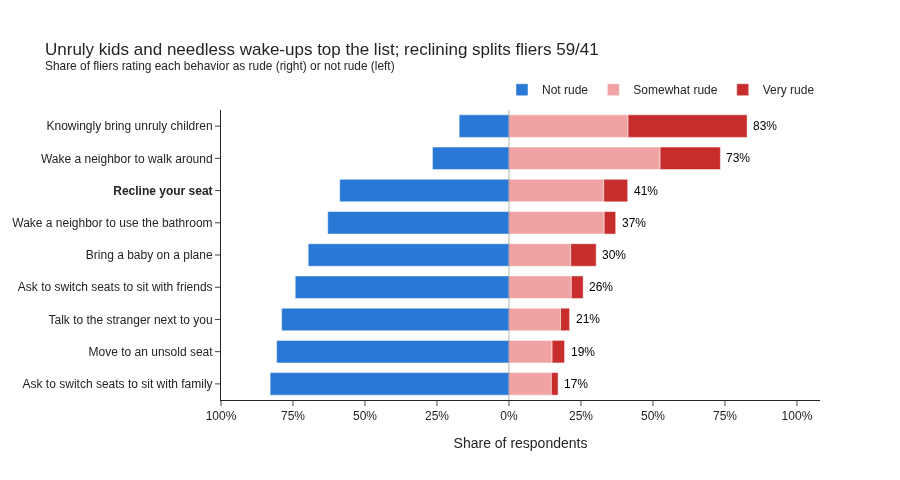

In [19]:
plot_df = rudeness.sort_values('rude')
y_labels = [f'<b>{b}</b>' if q == 'Q12' else b for q, b in zip(plot_df['qid'], plot_df['behavior'])]

fig = go.Figure()
fig.add_bar(y=y_labels, x=-plot_df['Not rude'], name='Not rude', orientation='h',
            marker_color=RUDE_COLORS['Not rude'], customdata=plot_df['Not rude'],
            hovertemplate='%{y}<br>Not rude: %{customdata:.0%}<extra></extra>')
for label in ['Somewhat rude', 'Very rude']:
    fig.add_bar(y=y_labels, x=plot_df[label], name=label, orientation='h',
                marker_color=RUDE_COLORS[label],
                hovertemplate='%{y}<br>' + label + ': %{x:.0%}<extra></extra>')
for y, total in zip(y_labels, plot_df['rude']):
    fig.add_annotation(x=total, y=y, text=f'{total:.0%}', showarrow=False, xanchor='left', xshift=4,
                       font=dict(size=12, color='black'))
fig.add_vline(x=0, line_color='black', line_width=1)
fig.update_layout(
    barmode='relative', bargap=0.3, height=480, width=900,
    title=dict(text='Unruly kids and needless wake-ups top the list; reclining splits fliers 59/41'
                    '<br><sup>Share of fliers rating each behavior as rude (right) or not rude (left)</sup>'),
    xaxis=dict(title='Share of respondents', tickformat='.0%', range=[-1, 1.08],
               tickvals=[-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1],
               ticktext=['100%', '75%', '50%', '25%', '0%', '25%', '50%', '75%', '100%']),
    yaxis_title=None, legend=dict(orientation='h', y=1.02, x=1, xanchor='right', yanchor='bottom',
                                  traceorder='normal'),
    margin=dict(t=110)
)
fig.show()

Reclining is rated rude by 41.2% of fliers (352 of 854), matching FiveThirtyEight's headline. It sits in the middle of the list: well below knowingly bringing unruly children (82.7%) or waking a neighbor just to walk around (73.4%), but far above talking to a stranger (21.1%) or moving to an empty seat (19.3%).

Two pairs of questions describe the **same act for different reasons**: waking a neighbor (to use the bathroom vs. to walk around) and asking to switch seats (to sit with friends vs. family). Comparing each respondent's two answers shows whether the reason matters.

In [20]:
def paired_shift(q_more_needed, q_less_needed, name):
    """Compare each respondent's rudeness score for the same act done for two different reasons."""
    d = fliers[[f'{q_more_needed}_score', f'{q_less_needed}_score']].dropna()
    more, less = d.iloc[:, 0], d.iloc[:, 1]
    return pd.Series({'n': len(d),
                      'less-needed reason rated ruder': (less > more).mean(),
                      'same rating': (less == more).mean(),
                      'more-needed reason rated ruder': (more > less).mean()}, name=name)


pd.DataFrame([
    paired_shift('Q16', 'Q17', 'Wake a neighbor: bathroom (Q16) vs. walk around (Q17)'),
    paired_shift('Q15', 'Q14', 'Switch seats: family (Q15) vs. friends (Q14)'),
]).astype({'n': int}).round(3)

,n,less-needed reason rated ruder,same rating,more-needed reason rated ruder
Wake a neighbor: bathroom (Q16) vs. walk around (Q17),850,0.499,0.488,0.013
Switch seats: family (Q15) vs. friends (Q14),850,0.109,0.882,0.008


The reason matters, and it pushes almost entirely in one direction. Half of fliers (49.9%) rate waking someone to stretch your legs as ruder than waking them for the bathroom; only 1.3% say the reverse. For seat swaps the effect is smaller — 10.9% think asking to sit with friends is ruder than asking to sit with family, versus 0.8% the other way — and most people (88.2%) treat the two requests alike. Etiquette here is judged by **necessity**, not by the act itself.

### 3. 👉 The recline paradox

Do the people who recline think it is fine, while those who never recline think it is rude? And how many recline while *also* saying it is rude?

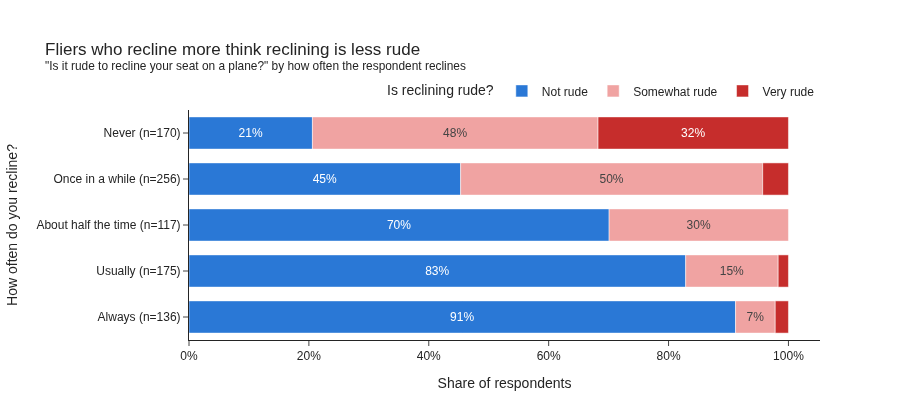

In [21]:
recline_rude = (fliers.dropna(subset=['Q12_label'])
                     .groupby(['recline_freq', 'Q12_label'], observed=True, as_index=False)
                     .agg(respondents=('RespondentID', 'size')))
recline_rude['share'] = recline_rude['respondents'] / recline_rude.groupby('recline_freq', observed=True)['respondents'].transform('sum')
group_n = recline_rude.groupby('recline_freq', observed=True)['respondents'].sum()
recline_rude['group'] = recline_rude['recline_freq'].map(lambda r: f'{r} (n={group_n[r]})').astype(str)

fig = px.bar(recline_rude, x='share', y='group', color='Q12_label', orientation='h',
             color_discrete_map=RUDE_COLORS, category_orders={'Q12_label': list(RUDE_COLORS),
                 'group': [f'{r} (n={group_n[r]})' for r in RECLINE_ORDER]},
             text=recline_rude['share'].map(lambda s: f'{s:.0%}' if s >= 0.05 else ''),
             labels={'share': 'Share of respondents', 'group': 'How often do you recline?',
                     'Q12_label': 'Is reclining rude?'},
             title='Fliers who recline more think reclining is less rude'
                   '<br><sup>"Is it rude to recline your seat on a plane?" by how often the respondent reclines</sup>')
fig.update_traces(textposition='inside', insidetextanchor='middle', hovertemplate='%{y}<br>%{x:.1%}<extra></extra>')
fig.update_layout(xaxis_tickformat='.0%', height=420, width=900, bargap=0.3,
                  legend=dict(orientation='h', y=1.02, x=1, xanchor='right', yanchor='bottom'),
                  margin=dict(t=110))
fig.show()

In [22]:
chi_square(fliers['recline_freq'], fliers['Q12_label'])

n                854
chi2           316.7
dof                8
p_value      < 0.001
cramers_v      0.431
dtype: object

The relationship is very strong (Cramér's V = 0.43): 79.4% of never-recliners call reclining rude, versus only 8.8% of those who always recline. Notice, though, that the "Once in a while" group is split almost evenly — 54.7% of them say it is rude. How common is reclining *despite* thinking it is rude?

In [23]:
says_rude = fliers['Q12_rude']
groups = {
    'All fliers': fliers.index,
    'Never recline': fliers.index[fliers['Q2'].eq('Never')],
    'Recline at least sometimes': fliers.index[fliers['Q2'].ne('Never')],
    '  ...once in a while': fliers.index[fliers['Q2'].eq('Once in a while')],
    '  ...about half the time': fliers.index[fliers['Q2'].eq('About half the time')],
    '  ...usually or always': fliers.index[fliers['reclines_often'].eq(1)],
}
hypocrisy = pd.DataFrame({name: share_with_ci(says_rude.loc[idx]) for name, idx in groups.items()}).T
hypocrisy['n'] = hypocrisy['n'].astype(int)
hypocrisy.rename(columns={'share': 'share_say_rude'}).round(3)

,n,share_say_rude,ci_low,ci_high
All fliers,854,0.412,0.380,0.446
Never recline,170,0.794,0.727,0.848
Recline at least sometimes,684,0.317,0.283,0.353
...once in a while,256,0.547,0.486,0.607
...about half the time,117,0.299,0.224,0.387
...usually or always,311,0.135,0.101,0.178


In [24]:
both = fliers.dropna(subset=['Q12_rude'])
recline_and_rude = (both['Q2'].ne('Never') & both['Q12_rude'].eq(1))
print(f'Recline at least sometimes AND say it is rude: {recline_and_rude.sum()} of {len(both)} fliers '
      f'({recline_and_rude.mean():.1%})')

Recline at least sometimes AND say it is rude: 217 of 854 fliers (25.4%)


**About one in three recliners (31.7%, 95% CI 28.3–35.3%) say reclining is rude** — 217 people, or 25.4% of all fliers. This "do it anyway" group is concentrated among occasional recliners: 54.7% of those who recline "once in a while" call it rude (nearly all say *somewhat* rude), against 13.5% of habitual recliners. A plausible reading is that many people treat reclining as a mildly rude act to be used sparingly, rather than as hypocrisy in the strict sense.

The survey also asked whether a recliner has an obligation to the person behind (Q11) and whether reclining should be banned outright (Q13).

In [25]:
stances = (fliers.groupby('recline_freq', observed=True, as_index=False)
                .agg(say_rude=('Q12_rude', 'mean'), must_stop_if_asked=('must_stop_if_asked', 'mean'),
                     would_ban=('would_ban', 'mean'), respondents=('RespondentID', 'size')))
stances.round(3)

,recline_freq,say_rude,must_stop_if_asked,would_ban,respondents
0,Never,0.794,0.859,0.653,171
1,Once in a while,0.547,0.754,0.348,257
2,About half the time,0.299,0.641,0.197,118
3,Usually,0.171,0.486,0.137,175
4,Always,0.088,0.324,0.088,137


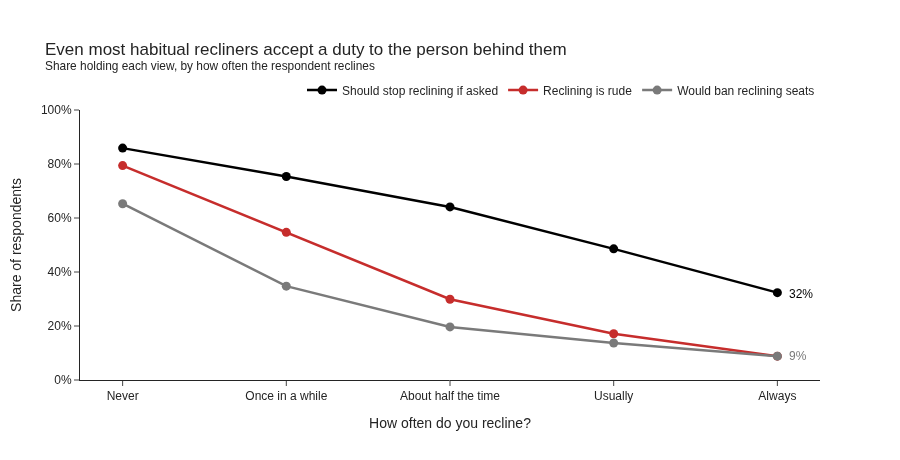

In [26]:
stance_labels = {'must_stop_if_asked': 'Should stop reclining if asked',
                 'say_rude': 'Reclining is rude',
                 'would_ban': 'Would ban reclining seats'}
stance_colors = {'Should stop reclining if asked': 'black', 'Reclining is rude': ACCENT,
                 'Would ban reclining seats': DARK_GRAY}
stances_long = (stances.melt(id_vars='recline_freq', value_vars=list(stance_labels),
                             var_name='stance', value_name='share')
                       .assign(stance=lambda d: d['stance'].map(stance_labels)))
stances_long['recline_freq'] = stances_long['recline_freq'].astype(str)

fig = px.line(stances_long, x='recline_freq', y='share', color='stance', markers=True,
              color_discrete_map=stance_colors, category_orders={'recline_freq': RECLINE_ORDER},
              labels={'recline_freq': 'How often do you recline?', 'share': 'Share of respondents',
                      'stance': ''},
              title='Even most habitual recliners accept a duty to the person behind them'
                    '<br><sup>Share holding each view, by how often the respondent reclines</sup>')
fig.update_traces(line_width=2.5, marker_size=9, hovertemplate='%{x}<br>%{y:.0%}<extra></extra>')
last = stances_long[stances_long['recline_freq'] == 'Always']
for share, grp in last.groupby(last['share'].round(2)):  # one label when lines end at the same value
    color = stance_colors[grp['stance'].iloc[0]] if len(grp) == 1 else DARK_GRAY
    fig.add_annotation(x='Always', y=share, text=f'{share:.0%}', showarrow=False,
                       xanchor='left', xshift=10, font=dict(color=color))
fig.update_layout(yaxis=dict(tickformat='.0%', range=[0, 1]), height=460, width=900,
                  legend=dict(orientation='h', y=1.02, x=1, xanchor='right', yanchor='bottom'),
                  margin=dict(t=110))
fig.show()

All three anti-reclining views fall steadily as recline frequency rises, but the *obligation* norm is the stickiest: 85.9% of never-recliners and still 32.4% of always-recliners say you should stop reclining if the person behind you asks. Banning reclining is a minority view overall (30.3%, from the Q13 counts above); only among never-recliners does a majority (65.3%) favor a ban.

Crossing the two attitude questions shows the four "camps" of fliers:

In [27]:
camps = pd.crosstab(fliers['Q12_rude'].map({0.0: 'Reclining is not rude', 1.0: 'Reclining is rude'}),
                    fliers['must_stop_if_asked'].map({0.0: 'No obligation to person behind',
                                                      1.0: 'Should stop if asked'}),
                    normalize='all', margins=True)
camps.round(3)

must_stop_if_asked,No obligation to person behind,Should stop if asked,All
Q12_rude,,,
Reclining is not rude,0.306,0.282,0.588
Reclining is rude,0.059,0.354,0.412
All,0.364,0.636,1.000


The most common position overall is "rude, and you should stop if asked" (35.4%), followed closely by two camps who see nothing wrong with reclining but split on the obligation: no obligation at all (30.6%) versus fine *unless the person behind asks* (28.2%). Almost nobody (5.9%) thinks reclining is rude yet owes nothing to the person behind. Across camps, **63.6% agree that a recliner should stop if asked** — the closest thing to a consensus rule in the data.

### 4. Does height explain who reclines?

A natural hypothesis is that taller people, who feel the squeeze of a reclined seat, are less likely to recline themselves or more likely to call it rude. Q3 is converted to inches ("Under 5 ft." coded as 59 and "6'6\" and above" as 78). A quick check that the conversion is sensible: average self-reported height by gender.

In [28]:
fliers.groupby('Gender', as_index=False).agg(respondents=('height_in', 'count'),
                                             mean_height_in=('height_in', 'mean'),
                                             median_height_in=('height_in', 'median')).round(1)

,Gender,respondents,mean_height_in,median_height_in
0,Female,442,64.8,65.0
1,Male,401,70.3,70.0


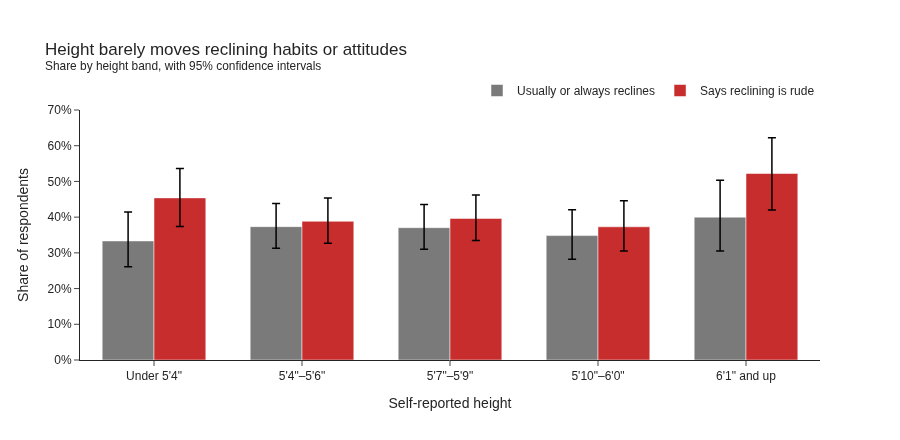

In [29]:
HEIGHT_BANDS = ['Under 5\'4"', '5\'4"–5\'6"', '5\'7"–5\'9"', '5\'10"–6\'0"', '6\'1" and up']
fliers['height_band'] = pd.cut(fliers['height_in'], bins=[0, 63, 66, 69, 72, 80], labels=HEIGHT_BANDS)

height_rows = []
for band in HEIGHT_BANDS:
    sub = fliers[fliers['height_band'] == band]
    for measure, col in [('Usually or always reclines', 'reclines_often'), ('Says reclining is rude', 'Q12_rude')]:
        height_rows.append({'height_band': band, 'measure': measure, **share_with_ci(sub[col]).to_dict()})
by_height = pd.DataFrame(height_rows)
by_height['n'] = by_height['n'].astype(int)

fig = px.bar(by_height, x='height_band', y='share', color='measure', barmode='group',
             color_discrete_map={'Usually or always reclines': DARK_GRAY, 'Says reclining is rude': ACCENT},
             error_y=by_height['ci_high'] - by_height['share'],
             error_y_minus=by_height['share'] - by_height['ci_low'],
             category_orders={'height_band': HEIGHT_BANDS}, custom_data=['n'],
             labels={'height_band': 'Self-reported height', 'share': 'Share of respondents', 'measure': ''},
             title='Height barely moves reclining habits or attitudes'
                   '<br><sup>Share by height band, with 95% confidence intervals</sup>')
fig.update_traces(hovertemplate='%{x}<br>%{y:.0%} (n=%{customdata[0]})<extra></extra>',
                  error_y=dict(color='black', thickness=1.5))
fig.update_layout(yaxis=dict(tickformat='.0%', range=[0, 0.7]), height=440, width=900, bargap=0.3,
                  legend=dict(orientation='h', y=1.02, x=1, xanchor='right', yanchor='bottom'),
                  margin=dict(t=110))
fig.show()

In [30]:
height_corr = []
for group, sub in [('All fliers', fliers), ('Women', fliers.query('Gender == "Female"')),
                   ('Men', fliers.query('Gender == "Male"'))]:
    for target, col in [('Recline frequency (0–4)', 'recline_score'), ('Rudeness of reclining (0–2)', 'Q12_score')]:
        d = sub[['height_in', col]].dropna()
        rho, p = stats.spearmanr(d['height_in'], d[col])
        height_corr.append({'group': group, 'height vs.': target, 'n': len(d),
                            'spearman_rho': round(rho, 3), 'p_value': fmt_p(p)})
pd.DataFrame(height_corr)

,group,height vs.,n,spearman_rho,p_value
0,All fliers,Recline frequency (0–4),858,0.007,0.829
1,All fliers,Rudeness of reclining (0–2),854,0.022,0.514
2,Women,Recline frequency (0–4),442,-0.011,0.818
3,Women,Rudeness of reclining (0–2),442,0.051,0.283
4,Men,Recline frequency (0–4),401,0.042,0.404
5,Men,Rudeness of reclining (0–2),401,0.021,0.681


In [31]:
pd.DataFrame({'Recline frequency (Q2)': chi_square(fliers['height_band'], fliers['Q2']),
              'Usually or always reclines': chi_square(fliers['height_band'], fliers['reclines_often']),
              'Says reclining is rude': chi_square(fliers['height_band'], fliers['Q12_rude'])}).T

,n,chi2,dof,p_value,cramers_v
Recline frequency (Q2),858,12.9,16,0.677,0.061
Usually or always reclines,858,1.4,4,0.846,0.04
Says reclining is rude,854,7.4,4,0.117,0.093


The height conversion looks sensible (women average 64.8 in., men 70.3 in.), yet **height has no detectable relationship with reclining**. Across five height bands, the share who usually or always recline stays between a third and two-fifths (33.3–40.0%), and the bands do not differ significantly (χ² p = 0.85). Spearman correlations are essentially zero for all fliers (ρ = 0.007 for recline frequency, ρ = 0.022 for rudeness) and within each gender.

The one hint of a pattern is that the tallest band (6'1" and up, n = 90) is the most likely to call reclining rude (52.2%, vs. 37.3–45.4% elsewhere). But the differences across bands are not significant (χ² p = 0.117), and the tallest band is almost entirely men, so this is a hypothesis for a larger sample rather than a finding. Whatever drives reclining habits, it is attitude, not legroom need — a useful null result.

### 5. Parents vs. non-parents on babies and unruly children

Q4 asks whether the respondent has children under 18. Do parents judge babies and unruly children on planes more leniently?

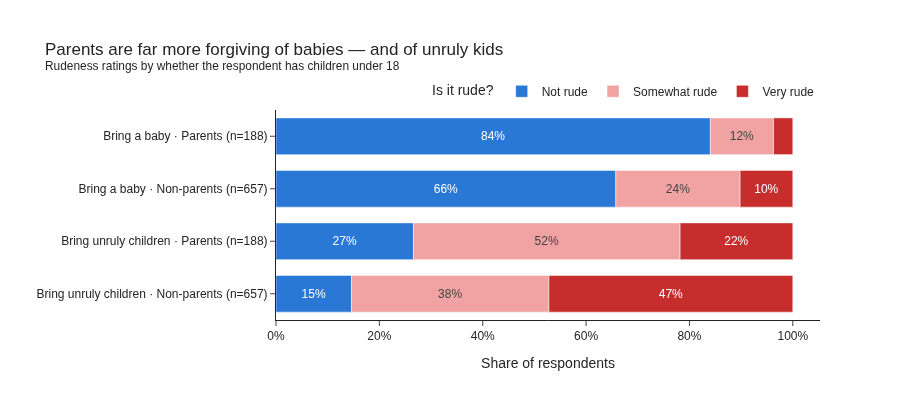

In [32]:
kid_rows = []
for qid, item in [('Q18', 'Bring a baby'), ('Q19', 'Bring unruly children')]:
    for parent_flag, who in [(1.0, 'Parents'), (0.0, 'Non-parents')]:
        labels = fliers.loc[fliers['parent'] == parent_flag, f'{qid}_label'].dropna()
        shares = labels.value_counts(normalize=True)
        for label in RUDE_COLORS:
            kid_rows.append({'group': f'{item} · {who} (n={len(labels)})', 'answer': label,
                             'share': shares.get(label, 0.0)})
kids = pd.DataFrame(kid_rows)

fig = px.bar(kids, x='share', y='group', color='answer', orientation='h', color_discrete_map=RUDE_COLORS,
             category_orders={'answer': list(RUDE_COLORS), 'group': list(dict.fromkeys(kids['group']))},
             text=kids['share'].map(lambda s: f'{s:.0%}' if s >= 0.05 else ''),
             labels={'share': 'Share of respondents', 'group': '', 'answer': 'Is it rude?'},
             title='Parents are far more forgiving of babies — and of unruly kids'
                   '<br><sup>Rudeness ratings by whether the respondent has children under 18</sup>')
fig.update_traces(textposition='inside', insidetextanchor='middle', hovertemplate='%{y}<br>%{x:.1%}<extra></extra>')
fig.update_layout(xaxis_tickformat='.0%', height=400, width=900, bargap=0.3,
                  legend=dict(orientation='h', y=1.02, x=1, xanchor='right', yanchor='bottom'),
                  margin=dict(t=110))
fig.show()

In [33]:
pd.DataFrame({'Baby (Q18)': chi_square(fliers['parent'], fliers['Q18_label']),
              'Unruly children (Q19)': chi_square(fliers['parent'], fliers['Q19_label'])}).T

,n,chi2,dof,p_value,cramers_v
Baby (Q18),845,23.5,2,< 0.001,0.167
Unruly children (Q19),845,41.2,2,< 0.001,0.221


In [34]:
fliers.groupby('Age', observed=True, as_index=False).agg(respondents=('parent', 'count'),
                                                         share_parents=('parent', 'mean')).round(3)

,Age,respondents,share_parents
0,18-29,171,0.070
1,30-44,221,0.425
2,45-60,234,0.299
3,> 60,213,0.052


Parenthood (of children under 18) is concentrated in the middle age groups — 42.5% of 30–44-year-olds and 29.9% of 45–60-year-olds, but only 7.0% of 18–29s and 5.2% of those over 60 — so a raw parent/non-parent gap could partly reflect age. Logistic regressions control for age group, gender, and flying frequency. The outcomes are "a baby on board is at least somewhat rude" and "unruly children are *very* rude"; the table shows odds ratios (OR < 1 means lower odds).

In [35]:
fliers['unruly_very_rude'] = (fliers['Q19_score'] == 2).astype(float).where(fliers['Q19_score'].notna())

def odds_ratios(formula, data, label):
    model = smf.logit(formula, data=data).fit(disp=0)
    ci = np.exp(model.conf_int())
    out = pd.DataFrame({'model': label, 'odds_ratio': np.exp(model.params), 'ci_low': ci[0], 'ci_high': ci[1],
                        'p_value': model.pvalues.map(fmt_p), 'n': int(model.nobs)})
    out = out.drop(index='Intercept').round(2)
    out.index = (out.index.str.replace(r'C\(Age.*\)\[T\.(.*)\]', r'Age \1 (vs. 18-29)', regex=True)
                          .str.replace('C(Gender)[T.Male]', 'Male (vs. female)', regex=False))
    return out

controls = 'C(Age, Treatment("18-29")) + C(Gender) + frequent_flier'
kid_models = pd.concat([
    odds_ratios(f'Q18_rude ~ parent + {controls}', fliers.dropna(subset=['Q18_rude', 'parent', 'Age', 'Gender']),
                'Baby is rude'),
    odds_ratios(f'unruly_very_rude ~ parent + {controls}',
                fliers.dropna(subset=['unruly_very_rude', 'parent', 'Age', 'Gender']), 'Unruly kids very rude'),
])
kid_models.loc[kid_models.index.isin(['parent', 'Male (vs. female)'])]

,model,odds_ratio,ci_low,ci_high,p_value,n
Male (vs. female),Baby is rude,2.02,1.48,2.74,< 0.001,839
parent,Baby is rude,0.30,0.19,0.47,< 0.001,839
Male (vs. female),Unruly kids very rude,1.71,1.28,2.27,< 0.001,839
parent,Unruly kids very rude,0.29,0.19,0.44,< 0.001,839


Only 16.0% of parents say bringing a baby on a plane is rude, versus 34.2% of non-parents. More surprisingly, parents are also softer on *knowingly* bringing unruly children — a choice by the accompanying adult, not something a child can help: 21.8% of parents call it "very rude" versus 47.2% of non-parents. Both gaps survive controls for age, gender, and flying frequency (adjusted OR ≈ 0.30 for the baby question and 0.29 for unruly kids, both p < 0.001). Gender matters independently: **men have about twice the odds of calling a baby on board rude** (OR 2.02), and higher odds of calling unruly kids very rude (OR 1.71).

*Caveat:* Q4 only asks about children *under 18*, so parents of adult children are counted as non-parents; the true parent/non-parent gap may be larger.

### 6. Who is the etiquette stickler? Age and gender

The table below shows, for each behavior, the share of each age group and gender who call it rude, with chi-square p-values for the full three-level answer. Reclining habits are included at the top.

In [36]:
demo_rows = []
items = [('Recline at least sometimes', fliers['Q2'].ne('Never').astype(float), fliers['Q2']),
         ('Usually or always recline', fliers['reclines_often'].astype(float), fliers['Q2'])]
items += [(f'Rude: {b.lower()}', fliers[f'{q}_rude'], fliers[f'{q}_label']) for q, b in RUDE_QUESTIONS.items()]
for name, flag, raw in items:
    by_age = flag.groupby(fliers['Age'], observed=True).mean()
    by_gender = flag.groupby(fliers['Gender']).mean()
    demo_rows.append({'measure': name, **by_age.round(3).to_dict(),
                      'p_age': chi_square(fliers['Age'], raw)['p_value'],
                      'Female': round(by_gender['Female'], 3), 'Male': round(by_gender['Male'], 3),
                      'p_gender': chi_square(fliers['Gender'], raw)['p_value']})
demo = pd.DataFrame(demo_rows).set_index('measure')
demo

,18-29,30-44,45-60,> 60,p_age,Female,Male,p_gender
measure,,,,,,,,
Recline at least sometimes,0.721,0.829,0.833,0.809,0.026,0.803,0.803,0.675
Usually or always recline,0.279,0.392,0.389,0.377,0.026,0.364,0.364,0.675
Rude: move to an unsold seat,0.244,0.194,0.162,0.167,0.060,0.167,0.212,0.229
Rude: talk to the stranger next to you,0.209,0.234,0.192,0.200,0.949,0.208,0.209,0.932
Rude: recline your seat,0.547,0.356,0.402,0.381,0.003,0.416,0.411,0.732
Rude: ask to switch seats to sit with friends,0.297,0.297,0.171,0.274,0.031,0.249,0.264,0.440
Rude: ask to switch seats to sit with family,0.180,0.216,0.090,0.205,0.013,0.176,0.165,0.898
Rude: wake a neighbor to use the bathroom,0.512,0.383,0.321,0.288,< 0.001,0.410,0.322,0.030
Rude: wake a neighbor to walk around,0.860,0.743,0.684,0.670,< 0.001,0.731,0.733,0.991


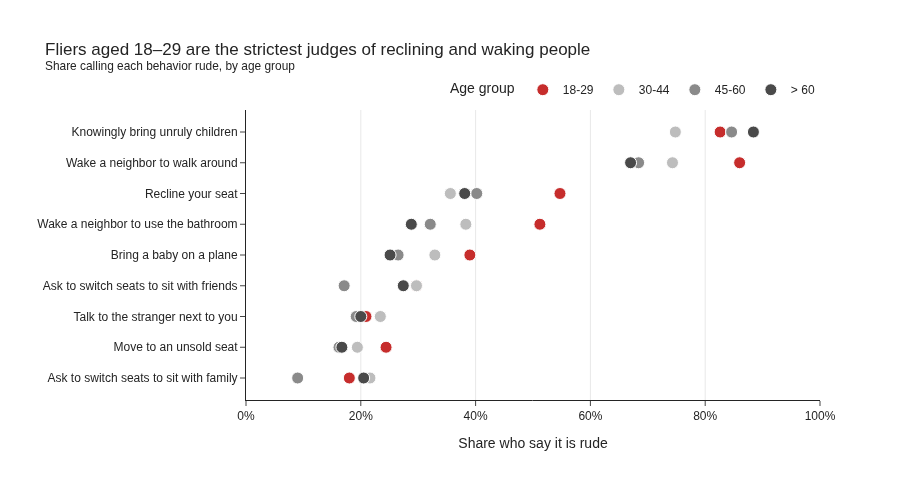

In [37]:
dots = (demo.loc[[f'Rude: {b.lower()}' for b in RUDE_QUESTIONS.values()], AGE_ORDER]
            .assign(order=lambda d: d.mean(axis=1)).sort_values('order').drop(columns='order')
            .reset_index().melt(id_vars='measure', var_name='Age group', value_name='share'))
dots['measure'] = dots['measure'].str.replace('Rude: ', '').str.capitalize()

age_colors = {'18-29': ACCENT, '30-44': '#bdbdbd', '45-60': '#8a8a8a', '> 60': '#4a4a4a'}
fig = px.scatter(dots, x='share', y='measure', color='Age group', color_discrete_map=age_colors,
                 category_orders={'Age group': AGE_ORDER},
                 labels={'share': 'Share who say it is rude', 'measure': ''},
                 title='Fliers aged 18–29 are the strictest judges of reclining and waking people'
                       '<br><sup>Share calling each behavior rude, by age group</sup>')
fig.update_traces(marker=dict(size=12, line=dict(width=1, color='white')),
                  hovertemplate='%{y}<br>%{x:.0%}<extra></extra>')
fig.update_layout(xaxis=dict(tickformat='.0%', range=[0, 1], showgrid=True), height=480, width=900,
                  legend=dict(orientation='h', y=1.02, x=1, xanchor='right', yanchor='bottom'),
                  margin=dict(t=110))
fig.show()

**Younger fliers are the stricter etiquette judges**, and they recline less. Among 18–29-year-olds, 54.7% say reclining is rude (35.6–40.2% in older groups), 51.2% say waking a neighbor for the bathroom is rude (28.8% of those over 60), and 86.0% say waking someone to walk around is rude (67.0% of those over 60). The youngest group is also the least likely to recline at all (72.1% vs. 80.9–83.3%). Some views are flat across ages: about one in five in every group thinks chatting with a seatmate is rude.

**Gender barely matters** except on children and sleep: men are much more likely to call a baby on board rude (37.9% vs. 23.5%, p < 0.001) and somewhat more likely to call unruly children rude (86.0% vs. 79.4%, p = 0.001), while women are more likely to call waking someone for the bathroom rude (41.0% vs. 32.2%, p = 0.030). Men and women recline at identical rates (36.4% usually or always).

Finally, a multivariate check on the headline question — what predicts saying reclining is rude, holding the other factors constant?

In [38]:
odds_ratios(f'Q12_rude ~ {controls} + parent',
            fliers.dropna(subset=['Q12_rude', 'Age', 'Gender', 'parent']), 'Reclining is rude')

,model,odds_ratio,ci_low,ci_high,p_value,n
Age 30-44 (vs. 18-29),Reclining is rude,0.54,0.35,0.83,0.005,839
Age 45-60 (vs. 18-29),Reclining is rude,0.61,0.41,0.92,0.020,839
Age > 60 (vs. 18-29),Reclining is rude,0.51,0.34,0.77,0.001,839
Male (vs. female),Reclining is rude,0.96,0.73,1.27,0.787,839
frequent_flier,Reclining is rude,1.44,1.05,1.96,0.022,839
parent,Reclining is rude,0.67,0.47,0.98,0.036,839


Holding other factors constant, every older age group has only about half to three-fifths the odds of the 18–29 group of calling reclining rude (ORs 0.51–0.61), parents have lower odds (OR 0.67), and gender has no effect. One counterintuitive result: **frequent fliers (more than once a year) are *more* likely to call reclining rude** (OR 1.44, p = 0.022). One possible explanation is that more exposure to cramped cabins hardens attitudes, but the survey cannot test this. These are modest effects in a non-probability sample, so treat them as directional.

### 7. Rule breakers: who are they, and do they recline more?

Q20 asks whether respondents have ever used electronics during takeoff or landing against a flight attendant's instructions; Q21 asks whether they have ever smoked in an airplane bathroom when it was against the rules.

In [39]:
fliers[['electronics', 'smoked']].agg(['sum', 'count', 'mean']).round(3)

,electronics,smoked
sum,136.00,7.000
count,849.00,849.000
mean,0.16,0.008


In [40]:
profile = pd.concat({
    'Age': fliers.groupby('Age', observed=True)['electronics'].apply(share_with_ci).unstack(),
    'Gender': fliers.groupby('Gender')['electronics'].apply(share_with_ci).unstack(),
    'Flies': fliers.groupby(fliers['frequent_flier'].map({0: 'Once a year or less', 1: 'More than once a year'}))
                   ['electronics'].apply(share_with_ci).unstack(),
})
profile['n'] = profile['n'].astype(int)
profile.rename(columns={'share': 'share_electronics_violators'}).round(3)

n  share_electronics_violators  ci_low  \
Age    18-29                  172                        0.297   0.233   
       30-44                  222                        0.212   0.163   
       45-60                  234                        0.107   0.073   
       > 60                   215                        0.060   0.036   
Gender Female                 442                        0.129   0.101   
       Male                   401                        0.197   0.161   
Flies  More than once a year  235                        0.268   0.216   
       Once a year or less    614                        0.119   0.096   

                              ci_high  
Age    18-29                    0.369  
       30-44                    0.270  
       45-60                    0.153  
       > 60                     0.101  
Gender Female                   0.163  
       Male                     0.239  
Flies  More than once a year    0.328  
       Once a year or less      0.147

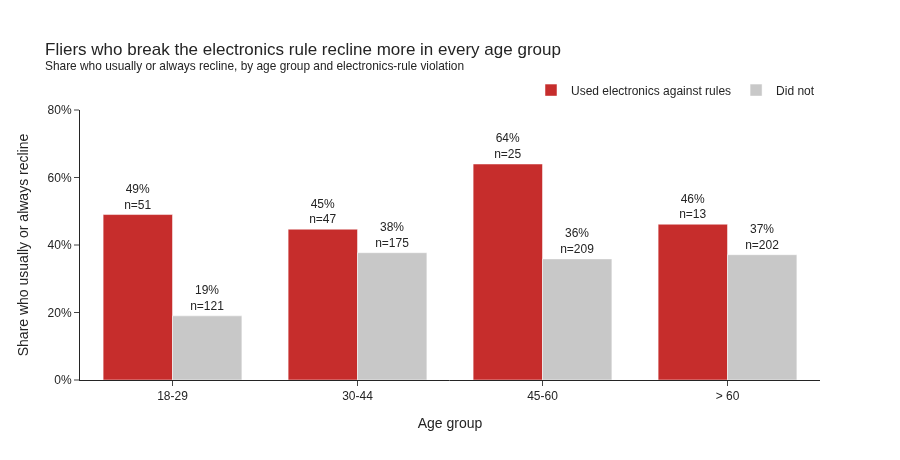

In [41]:
rb = (fliers.dropna(subset=['electronics'])
            .assign(violator=lambda d: d['electronics'].map({1.0: 'Used electronics against rules', 0.0: 'Did not'}))
            .groupby(['Age', 'violator'], observed=True, as_index=False)
            .agg(share=('reclines_often', 'mean'), n=('reclines_often', 'size')))
rb['Age'] = rb['Age'].astype(str)

fig = px.bar(rb, x='Age', y='share', color='violator', barmode='group', custom_data=['n'],
             color_discrete_map={'Used electronics against rules': ACCENT, 'Did not': GRAY},
             category_orders={'violator': ['Used electronics against rules', 'Did not'], 'Age': AGE_ORDER},
             text=rb.apply(lambda r: f"{r['share']:.0%}<br>n={r['n']}", axis=1),
             labels={'Age': 'Age group', 'share': 'Share who usually or always recline', 'violator': ''},
             title='Fliers who break the electronics rule recline more in every age group'
                   '<br><sup>Share who usually or always recline, by age group and electronics-rule violation</sup>')
fig.update_traces(textposition='outside', hovertemplate='%{x}<br>%{y:.0%} (n=%{customdata[0]})<extra></extra>')
fig.update_layout(yaxis=dict(tickformat='.0%', range=[0, 0.8]), height=460, width=900, bargap=0.25,
                  legend=dict(orientation='h', y=1.02, x=1, xanchor='right', yanchor='bottom'),
                  margin=dict(t=110))
fig.show()

In [42]:
odds_ratios(f'reclines_often ~ electronics + {controls}',
            fliers.dropna(subset=['electronics', 'Age', 'Gender']), 'Usually/always reclines')

,model,odds_ratio,ci_low,ci_high,p_value,n
Age 30-44 (vs. 18-29),Usually/always reclines,1.81,1.17,2.81,0.008,843
Age 45-60 (vs. 18-29),Usually/always reclines,2.01,1.29,3.13,0.002,843
Age > 60 (vs. 18-29),Usually/always reclines,1.95,1.24,3.07,0.004,843
Male (vs. female),Usually/always reclines,0.95,0.71,1.27,0.727,843
electronics,Usually/always reclines,2.52,1.68,3.77,< 0.001,843
frequent_flier,Usually/always reclines,0.69,0.49,0.96,0.027,843


In [43]:
smokers = fliers.query('smoked == 1')
print(f'Smokers: {len(smokers)}; of these, {int(smokers["electronics"].sum())} also used electronics against the rules '
      f'and {int(smokers["reclines_often"].sum())} usually or always recline.')

Smokers: 7; of these, 6 also used electronics against the rules and 5 usually or always recline.


16.0% of fliers (136 of 849) admit using electronics against a flight attendant's direction. Rule breaking falls steeply with age — 29.7% of 18–29-year-olds versus 6.0% of those over 60 — and is more common among men (19.7% vs. 12.9%) and frequent fliers (26.8% vs. 11.9%).

Rule breakers also recline more: in every age group, a larger share of violators usually or always recline (e.g., 49.0% vs. 19.0% among 18–29-year-olds). Controlling for age, gender, and flying frequency, electronics violators have **2.5 times the odds** of being habitual recliners (95% CI 1.68–3.77). This suggests a general "my seat, my rules" disposition — though a survey can't tell us which way, if any, the causation runs. The violator subgroups in the two oldest age bands are small (n = 25 and 13), so the age-specific bars there are noisy; the pooled odds ratio is the more reliable number. The same model also shows that frequent fliers are *less* likely to recline habitually (OR 0.69), consistent with their harsher view of reclining in Section 6.

Only 7 fliers admit to smoking in the lavatory, too few for any statistics; 6 of the 7 also broke the electronics rule and 5 usually or always recline.

### 8. Shared-space norms: armrests and the window shade

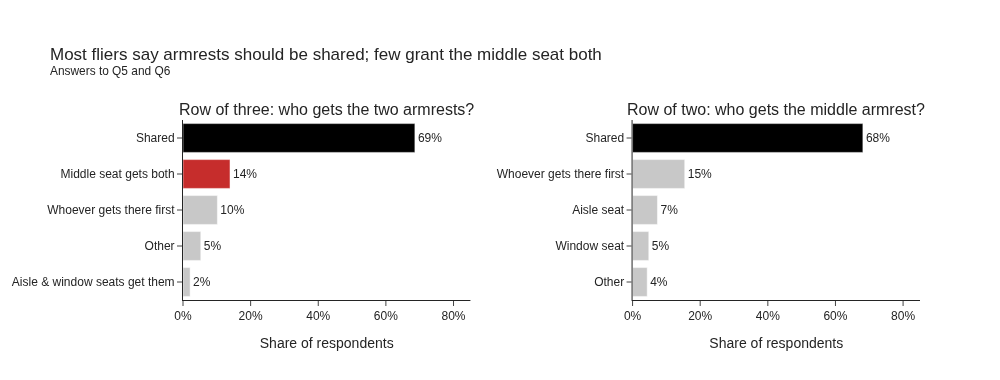

In [44]:
ARMREST_SHORT = {
    'The arm rests should be shared': 'Shared',
    'Whoever puts their arm on the arm rest first': 'Whoever gets there first',
    'The person in the middle seat gets both arm rests': 'Middle seat gets both',
    'The people in the aisle and window seats get both arm rests': 'Aisle & window seats get them',
    'The person in aisle': 'Aisle seat',
    'The person by the window': 'Window seat',
    'Other (please specify)': 'Other',
}
fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.22,
                    subplot_titles=['Row of three: who gets the two armrests?',
                                    'Row of two: who gets the middle armrest?'])
for col, qid in enumerate(['Q5', 'Q6'], start=1):
    shares = fliers[qid].map(ARMREST_SHORT).value_counts(normalize=True).sort_values()
    colors = ['black' if k == 'Shared' else (ACCENT if k == 'Middle seat gets both' else GRAY) for k in shares.index]
    fig.add_bar(x=shares.values, y=shares.index, orientation='h', marker_color=colors, showlegend=False,
                text=[f'{v:.0%}' for v in shares.values], textposition='outside', row=1, col=col,
                hovertemplate='%{y}: %{x:.1%}<extra></extra>')
fig.update_xaxes(tickformat='.0%', range=[0, 0.85], title_text='Share of respondents')
fig.update_layout(title=dict(text='Most fliers say armrests should be shared; few grant the middle seat both'
                                  '<br><sup>Answers to Q5 and Q6</sup>'),
                  height=380, width=1000, margin=dict(t=120))
fig.show()

In [45]:
shade = (fliers.groupby(['Age', 'Q7'], observed=True, as_index=False)
              .agg(respondents=('RespondentID', 'size')))
shade['share'] = shade['respondents'] / shade.groupby('Age', observed=True)['respondents'].transform('sum')
display(fliers['Q7'].value_counts(normalize=True).round(3))
display(shade.query('Q7.str.startswith("The person")', engine='python')[['Age', 'respondents', 'share']].round(3))
chi_square(fliers['Age'], fliers['Q7'])

Q7
Everyone in the row should have some say                       0.578
The person in the window seat should have exclusive control    0.422
Name: proportion, dtype: float64

,Age,respondents,share
1,18-29,67,0.390
3,30-44,116,0.523
5,45-60,95,0.406
7,> 60,75,0.349


n              843
chi2          14.9
dof              3
p_value      0.002
cramers_v    0.133
dtype: object

In [46]:
arm_recline = (fliers.dropna(subset=['Q5'])
                     .assign(armrest_view=lambda d: d['Q5'].map(ARMREST_SHORT))
                     .groupby('armrest_view', as_index=False)
                     .agg(respondents=('reclines_often', 'size'), share_reclines_often=('reclines_often', 'mean'))
                     .sort_values('share_reclines_often', ascending=False))
display(arm_recline.round(3))
chi_square(fliers['Q5'], fliers['reclines_often'])

,armrest_view,respondents,share_reclines_often
4,Whoever gets there first,87,0.506
2,Other,45,0.444
1,Middle seat gets both,119,0.378
3,Shared,587,0.342
0,Aisle & window seats get them,18,0.111


n              856
chi2          15.1
dof              4
p_value      0.005
cramers_v    0.133
dtype: object

Armrest norms are cooperative: 68.6% (row of three) and 68.1% (row of two) say armrests should be shared. Only 13.9% give the middle-seat passenger both armrests in a row of three — a popular "rule" in etiquette columns that most fliers don't endorse. "Whoever gets there first" is more common in a row of two (15.4%) than a row of three (10.2%).

The window shade is more contested: 57.8% say everyone in the row should have a say, while 42.2% give the window seat exclusive control. The 30–44 group is the only one where a majority (52.3%) sides with the window seat (χ² p = 0.002).

First-come-first-served armrest views go along with reclining: 50.6% of those who say "whoever gets there first" usually or always recline, versus 34.2% of those who say "shared" (n = 87 vs. 587; overall χ² p = 0.005). Like the electronics result, this points to a consistent "claim your space" mindset, though the subgroup is small.

## Key Findings

- **Reclining divides fliers 59/41, and attitudes track behavior.** 41.2% call reclining rude, but that ranges from 79.4% of never-recliners to 8.8% of always-recliners (Cramér's V = 0.43).
- **About one in three recliners (31.7%, 95% CI 28.3–35.3%) say reclining is rude** — a quarter of all fliers. This group is mostly occasional recliners; only 13.5% of habitual recliners say it is rude.
- **"Stop if the person behind asks" is the closest thing to a consensus**: 63.6% agree, including 32.4% of people who always recline. Only 30.3% would ban reclining outright.
- **Necessity, not the act, drives judgments**: half of fliers (49.9%) rate waking a neighbor to walk around as ruder than waking them for the bathroom; just 1.3% say the reverse.
- **Height doesn't explain reclining** — Spearman ρ = 0.007 between height and recline frequency (p = 0.83), with no significant differences across height bands for habits or attitudes, even within gender.
- **Parents are much more forgiving of children on planes**: 16.0% vs. 34.2% call a baby rude, and 21.8% vs. 47.2% call unruly kids very rude; both gaps hold after controlling for age, gender, and flying frequency (OR ≈ 0.3). Men have twice the odds of women of calling a baby rude.
- **Young fliers are the strictest judges, and rule breakers recline more.** 18–29-year-olds are most likely to call reclining (54.7%) and waking people rude, yet most likely to break the electronics rule (29.7%). Electronics violators have 2.5× the odds of habitual reclining after controls.

## Case Study Potential

**Verdict: Strong.** The data set is small, clean, and instantly relatable — every student has an opinion about reclining — yet it supports genuinely non-obvious findings: a sizable "recline anyway" group, a sticky obligation norm, a clean null result for height, and a parent effect that survives controls. It also teaches survey-specific issues (skip logic, missing-data patterns, a non-random online panel) that most textbook data sets hide.

**Suggested framing:** An airline's customer-experience team is deciding whether to switch its new narrow-body fleet to "pre-reclined" (fixed-recline) seats, as some low-cost carriers have done, and how to word its onboard etiquette messaging. Using this survey, students must estimate how many passengers would welcome or resent the change, identify which customer segments care most, and recommend whether to ban recline or instead promote a "check with the person behind you" norm.

**Analytics skills exercised:** data cleaning and recoding (renaming questions, fixing labels, converting height strings to inches), handling skip-logic missingness and defining an analysis base, `groupby`/`crosstab` with ordered categoricals, encoding ordinal Likert answers, chi-square tests and Cramér's V, confidence intervals for proportions, paired comparisons, logistic regression with controls (confounding by age), and diverging/100%-stacked bar charts.

**Candidate student questions:**
1. How did the survey handle people who never fly, and how does excluding them change who the results represent?
2. What share of people who recline believe reclining is rude? How should we interpret this group — hypocrites, or people who treat reclining as an occasional, mildly rude act?
3. Is the parent/non-parent gap in attitudes toward babies explained by age or gender? Use a logistic regression to check.
4. Does height predict reclining? What does a convincing null result look like, and why is it worth reporting?
5. Based on the data, would you recommend banning recline, keeping it, or promoting a "stop if asked" norm? Which segments would be most affected?

**Main data limitations:** a 2014 SurveyMonkey Audience opt-in panel (not a probability sample; no weights provided), self-reported behavior and height, coarse categorical answers (e.g., age bands, top- and bottom-coded heights), "children under 18" misses parents of adult children, a few small subgroups (e.g., only 7 lavatory smokers), and the electronics question was asked shortly after the FAA relaxed its takeoff-and-landing device restrictions in late 2013, so "violations" may refer to different rule regimes.